#### ============================================
#### CHANAKYA - AI Commerce Intelligence Platform
#### Layer 7: ML Demand Forecasting
#### Author: Devesh Shukla
#### ============================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paths
PROCESSED_PATH = r'C:\Users\Dell\CHANAKYA\data\processed'
ML_PATH = r'C:\Users\Dell\CHANAKYA\layer7_ml_forecasting'

# Load data
df_orders = pd.read_csv(f'{PROCESSED_PATH}/orders_processed.csv')
df_order_items = pd.read_csv(f'{PROCESSED_PATH}/order_items_processed.csv')
df_products = pd.read_csv(f'{PROCESSED_PATH}/products_processed.csv')

# Parse dates
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'],      format='mixed')
df_order_items['order_date'] = pd.to_datetime(df_order_items['order_date'], format='mixed')

print("=" * 55)
print("   CHANAKYA — LAYER 7: ML DEMAND FORECASTING")
print("=" * 55)
print(f"\nData loaded successfully!")
print(f"  Orders      : {len(df_orders):,}")
print(f"  Order Items : {len(df_order_items):,}")
print(f"  Products    : {len(df_products):,}")
print(f"\nML Forecasting started!")

   CHANAKYA — LAYER 7: ML DEMAND FORECASTING

Data loaded successfully!
  Orders      : 5,010
  Order Items : 8,769
  Products    : 50

ML Forecasting started!


#### ============================================
#### FEATURE ENGINEERING FOR ML
#### ============================================

In [2]:
print("=" * 55)
print("   FEATURE ENGINEERING")
print("=" * 55)

# Delivered orders only
delivered = df_order_items[df_order_items['order_status'] == 'Delivered'].copy()

# Monthly product demand
monthly_demand = delivered.groupby(
    ['order_year', 'order_month', 'product_id', 'product_name', 'category']
).agg(
    units_sold = ('quantity', 'sum'),
    revenue = ('revenue',  'sum'),
    orders = ('order_id', 'nunique')
).reset_index()

# Merge product features
monthly_demand = monthly_demand.merge(
    df_products[['product_id', 'price', 'cost_price', 'profit_margin', 'stock']],
    on='product_id', how='left'
)

# Time features
monthly_demand['period'] = monthly_demand['order_year'] * 100 + monthly_demand['order_month']
monthly_demand['is_festive'] = monthly_demand['order_month'].isin([10, 11, 12]).astype(int)
monthly_demand['is_summer'] = monthly_demand['order_month'].isin([4, 5, 6]).astype(int)
monthly_demand['quarter'] = monthly_demand['order_month'].apply(
    lambda m: 1 if m<=3 else 2 if m<=6 else 3 if m<=9 else 4)

# Category encoding
monthly_demand['category_code'] = monthly_demand['category'].astype('category').cat.codes

# Lag features — previous month demand
monthly_demand = monthly_demand.sort_values(['product_id', 'period'])
monthly_demand['lag1_units'] = monthly_demand.groupby('product_id')['units_sold'].shift(1)
monthly_demand['lag2_units'] = monthly_demand.groupby('product_id')['units_sold'].shift(2)
monthly_demand['rolling_avg3'] = monthly_demand.groupby('product_id')['units_sold'].transform(
    lambda x: x.rolling(3, min_periods=1).mean().shift(1))

# Drop NaN
monthly_demand = monthly_demand.dropna()

print(f"\nFeature Engineering Complete!")
print(f"  Total Records : {len(monthly_demand):,}")
print(f"  Products : {monthly_demand['product_id'].nunique()}")
print(f"  Date Range : {monthly_demand['period'].min()} to {monthly_demand['period'].max()}")

print(f"\nFeatures created:")
features = ['order_month', 'order_year', 'price', 'cost_price',
            'profit_margin', 'stock', 'is_festive', 'is_summer',
            'quarter', 'category_code', 'lag1_units', 'lag2_units',
            'rolling_avg3']
for f in features:
    print(f"  - {f}")

print(f"\nTarget Variable: units_sold")
print(f"  Min : {monthly_demand['units_sold'].min()}")
print(f"  Max : {monthly_demand['units_sold'].max()}")
print(f"  Mean : {monthly_demand['units_sold'].mean():.2f}")

   FEATURE ENGINEERING

Feature Engineering Complete!
  Total Records : 1,588
  Products : 50
  Date Range : 202303 to 202603

Features created:
  - order_month
  - order_year
  - price
  - cost_price
  - profit_margin
  - stock
  - is_festive
  - is_summer
  - quarter
  - category_code
  - lag1_units
  - lag2_units
  - rolling_avg3

Target Variable: units_sold
  Min : 1
  Max : 31
  Mean : 5.20


#### ============================================
#### MODEL TRAINING & COMPARISON
#### 4 Models — Linear Regression, Decision Tree,
#### Random Forest, Gradient Boosting
#### ============================================

In [3]:
print("=" * 55)
print("   MODEL TRAINING & EVALUATION")
print("=" * 55)

# Features & Target
features = ['order_month', 'order_year', 'price', 'cost_price',
            'profit_margin', 'stock', 'is_festive', 'is_summer',
            'quarter', 'category_code', 'lag1_units', 'lag2_units',
            'rolling_avg3']

X = monthly_demand[features]
y = monthly_demand['units_sold']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nDataset Split:")
print(f"  Training samples : {len(X_train):,}")
print(f"  Testing samples : {len(X_test):,}")

# Define Models
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=8),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100),
}

results = {}
predictions = {}

print(f"\nTraining Models...")
print(f"-" * 55)
print(f"  {'Model':<22} {'R2':>8} {'RMSE':>10} {'MAE':>10} {'CV Score':>10}")
print(f"  {'-'*22} {'-'*8} {'-'*10} {'-'*10} {'-'*10}")

for name, model in models.items():
    # Use scaled data for Linear Regression
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

    # Clip negative predictions
    y_pred = np.clip(y_pred, 0, None)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    cv = cv_scores.mean()

    results[name]     = {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'CV': cv}
    predictions[name] = y_pred

    print(f"  {name:<22} {r2:>8.4f} {rmse:>10.4f} {mae:>10.4f} {cv:>10.4f}")

# Best model
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = models[best_model_name]
best_r2 = results[best_model_name]['R2']

print(f"\n  Best Model : {best_model_name}")
print(f"  Best R2 : {best_r2:.4f}")

   MODEL TRAINING & EVALUATION

Dataset Split:
  Training samples : 1,270
  Testing samples : 318

Training Models...
-------------------------------------------------------
  Model                        R2       RMSE        MAE   CV Score
  ---------------------- -------- ---------- ---------- ----------
  Linear Regression        0.2652     2.8711     2.2718     0.2095
  Decision Tree            0.0780     3.2162     2.5164    -0.2055
  Random Forest            0.2522     2.8964     2.3389     0.1804
  Gradient Boosting        0.2891     2.8240     2.2469     0.2209

  Best Model : Gradient Boosting
  Best R2 : 0.2891


#### ============================================
#### FEATURE IMPORTANCE + VISUALIZATION
#### ============================================

   FEATURE IMPORTANCE ANALYSIS

Top Features — Random Forest:
  Feature             RF Importance  GB Importance
  ------------------ -------------- --------------
  order_month                0.1367         0.2064
  order_year                 0.1092         0.2187
  rolling_avg3               0.1089         0.0528
  profit_margin              0.0961         0.0523
  lag1_units                 0.0920         0.0393
  lag2_units                 0.0861         0.0299
  is_festive                 0.0775         0.1671
  category_code              0.0638         0.0281
  stock                      0.0629         0.0295
  quarter                    0.0582         0.1228
  price                      0.0529         0.0161
  cost_price                 0.0522         0.0359
  is_summer                  0.0034         0.0010


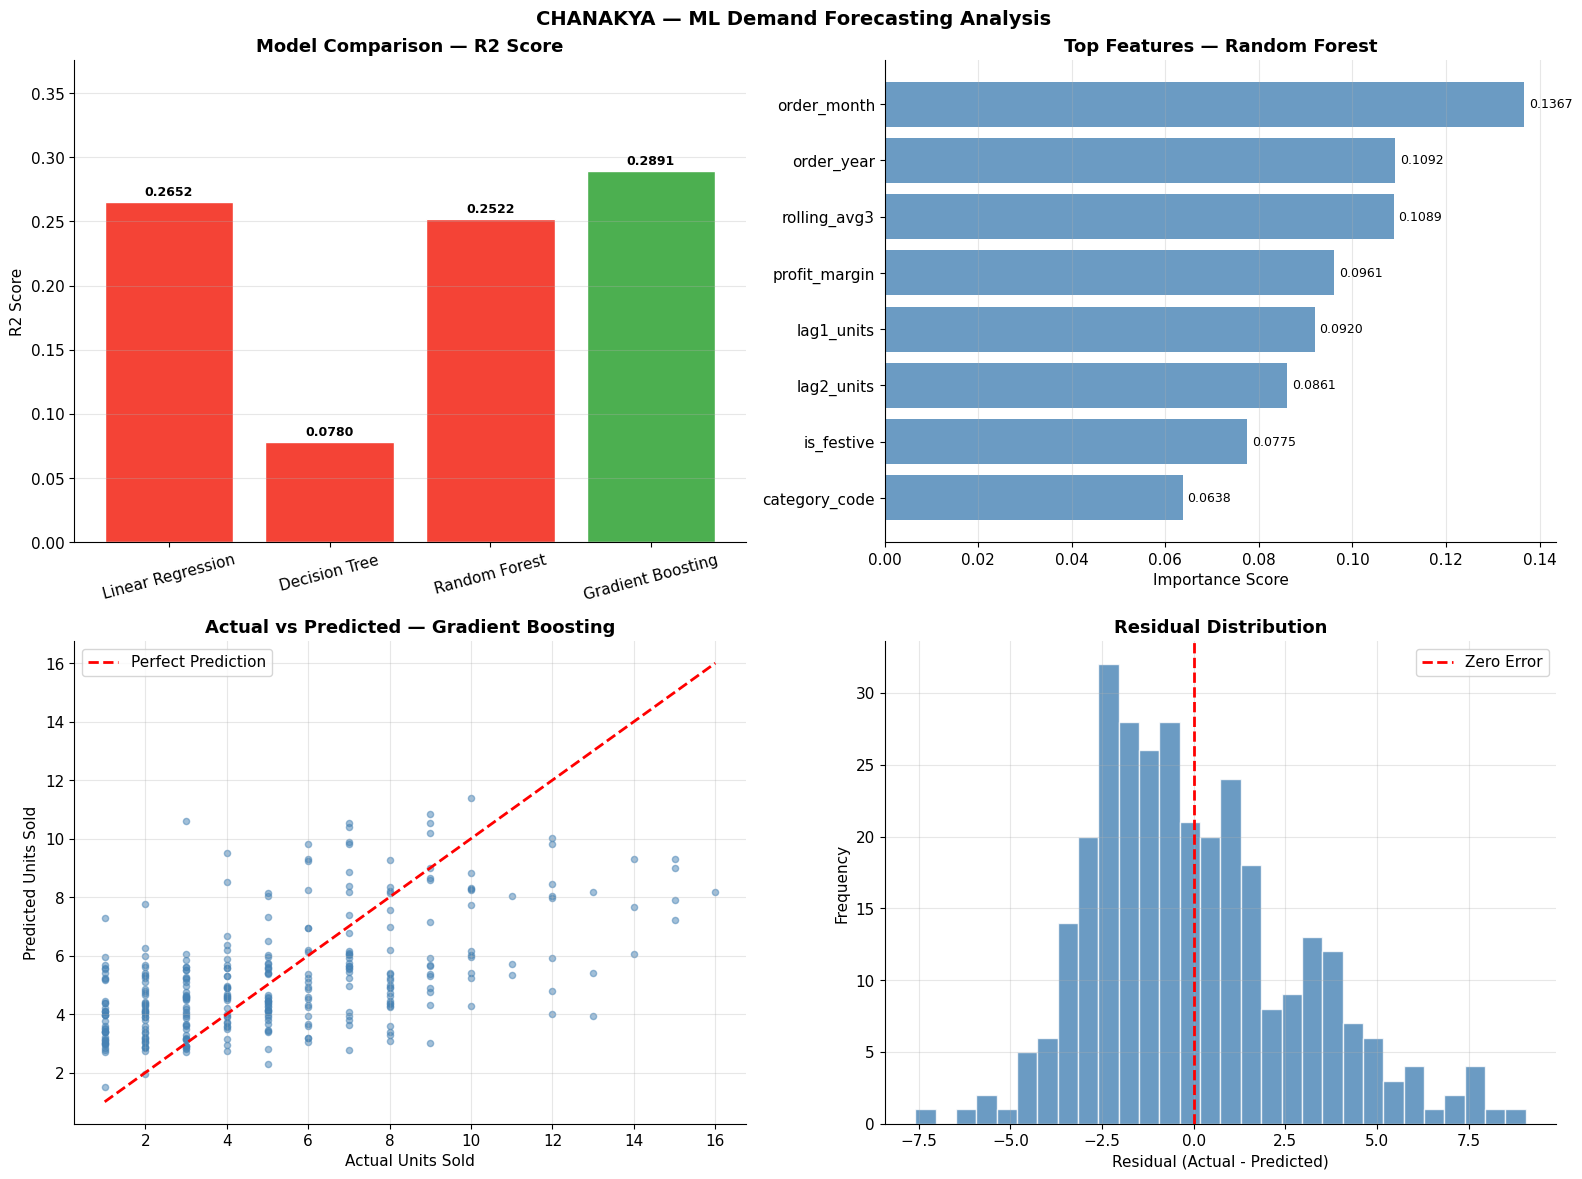

Chart saved: 08_ml_forecasting.png


In [4]:
print("=" * 55)
print("   FEATURE IMPORTANCE ANALYSIS")
print("=" * 55)

# Random Forest Feature Importance
rf_model    = models['Random Forest']
gb_model    = models['Gradient Boosting']

importance_df = pd.DataFrame({
    'feature'           : features,
    'rf_importance'     : rf_model.feature_importances_,
    'gb_importance'     : gb_model.feature_importances_,
}).sort_values('rf_importance', ascending=False)

print(f"\nTop Features — Random Forest:")
print(f"  {'Feature':<18} {'RF Importance':>14} {'GB Importance':>14}")
print(f"  {'-'*18} {'-'*14} {'-'*14}")
for _, row in importance_df.iterrows():
    print(f"  {row['feature']:<18} {row['rf_importance']:>14.4f} {row['gb_importance']:>14.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — Model Comparison
model_names = list(results.keys())
r2_scores   = [results[m]['R2']   for m in model_names]
rmse_scores = [results[m]['RMSE'] for m in model_names]
colors      = ['#F44336' if m != best_model_name else '#4CAF50' for m in model_names]

bars = axes[0,0].bar(model_names, r2_scores, color=colors, edgecolor='white')
axes[0,0].set_title('Model Comparison — R2 Score', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('R2 Score')
axes[0,0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, r2_scores):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0,0].grid(axis='y', alpha=0.3)
axes[0,0].set_ylim(0, max(r2_scores) * 1.3)

# Plot 2 — Feature Importance
imp_top = importance_df.head(8).sort_values('rf_importance')
axes[0,1].barh(imp_top['feature'], imp_top['rf_importance'],
               color='steelblue', alpha=0.8)
axes[0,1].set_title('Top Features — Random Forest', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Importance Score')
for i, val in enumerate(imp_top['rf_importance']):
    axes[0,1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
axes[0,1].grid(axis='x', alpha=0.3)

# Plot 3 — Actual vs Predicted — Best Model
if best_model_name == 'Linear Regression':
    y_pred_best = predictions['Linear Regression']
else:
    y_pred_best = predictions[best_model_name]

axes[1,0].scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', s=20)
axes[1,0].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()],
               'r--', linewidth=2, label='Perfect Prediction')
axes[1,0].set_title(f'Actual vs Predicted — {best_model_name}',
                    fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Actual Units Sold')
axes[1,0].set_ylabel('Predicted Units Sold')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Plot 4 — Residuals
residuals = y_test.values - y_pred_best
axes[1,1].hist(residuals, bins=30, color='steelblue',
               edgecolor='white', alpha=0.8)
axes[1,1].axvline(x=0, color='red', linestyle='--',
                   linewidth=2, label='Zero Error')
axes[1,1].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Residual (Actual - Predicted)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle('CHANAKYA — ML Demand Forecasting Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ML_PATH}/08_ml_forecasting.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 08_ml_forecasting.png")

#### ============================================
#### FUTURE DEMAND PREDICTION
#### ============================================

In [5]:
print("=" * 55)
print("   FUTURE DEMAND PREDICTION")
print("=" * 55)

# Predict next 3 months demand for top 10 products
top_products = delivered.groupby(
    ['product_id', 'product_name', 'category']
)['quantity'].sum().nlargest(10).reset_index()

future_months = [
    {'order_year': 2026, 'order_month': 4, 'label': 'Apr 2026'},
    {'order_year': 2026, 'order_month': 5, 'label': 'May 2026'},
    {'order_year': 2026, 'order_month': 6, 'label': 'Jun 2026'},
]

# Get latest lag values per product
latest_lag = monthly_demand.groupby('product_id').last().reset_index()

print(f"\nPredicted Demand — Next 3 Months:")
print(f"  {'Product':<28} {'Category':<15} {'Apr':>6} {'May':>6} {'Jun':>6}")
print(f"  {'-'*28} {'-'*15} {'-'*6} {'-'*6} {'-'*6}")

all_predictions = []

for _, prod in top_products.iterrows():
    pid      = prod['product_id']
    pname    = prod['product_name']
    pcat     = prod['category']
    prod_row = df_products[df_products['product_id'] == pid].iloc[0]
    lag_row  = latest_lag[latest_lag['product_id'] == pid]

    if len(lag_row) == 0:
        continue

    lag_row   = lag_row.iloc[0]
    month_preds = []

    for fm in future_months:
        feat = pd.DataFrame([{
            'order_month'   : fm['order_month'],
            'order_year'    : fm['order_year'],
            'price'         : prod_row['price'],
            'cost_price'    : prod_row['cost_price'],
            'profit_margin' : prod_row['profit_margin'],
            'stock'         : prod_row['stock'],
            'is_festive'    : 1 if fm['order_month'] in [10,11,12] else 0,
            'is_summer'     : 1 if fm['order_month'] in [4,5,6]    else 0,
            'quarter'       : 2,
            'category_code' : monthly_demand[
                monthly_demand['product_id']==pid
            ]['category_code'].iloc[0],
            'lag1_units'    : lag_row['units_sold'],
            'lag2_units'    : lag_row['lag1_units'],
            'rolling_avg3'  : lag_row['rolling_avg3'],
        }])

        pred = gb_model.predict(feat)[0]
        pred = max(1, round(pred))
        month_preds.append(pred)

    preds = month_preds
    print(f"  {pname[:28]:<28} {pcat[:15]:<15} "
          f"{preds[0]:>6} {preds[1]:>6} {preds[2]:>6}")

    all_predictions.append({
        'product_id'   : pid,
        'product_name' : pname,
        'category'     : pcat,
        'apr_2026'     : preds[0],
        'may_2026'     : preds[1],
        'jun_2026'     : preds[2],
        'total_q2'     : sum(preds)
    })

# Save predictions
pred_df = pd.DataFrame(all_predictions)
pred_df.to_csv(f'{ML_PATH}/demand_predictions.csv', index=False)

print(f"\nPredictions saved: demand_predictions.csv")

   FUTURE DEMAND PREDICTION

Predicted Demand — Next 3 Months:
  Product                      Category           Apr    May    Jun
  ---------------------------- --------------- ------ ------ ------
  Zebronics Zeb-County         Electronics          5      5      5
  Realme Narzo 60              Electronics          4      4      4
  Biba Anarkali Suit           Clothing             4      4      4
  Classmate Notebook Pack      Books                3      3      3
  Cosco Cricket Kit            Sports               3      3      3
  Lakme 9to5 Foundation        Beauty               4      4      4
  Park Avenue Deo Combo        Beauty               3      3      3
  Nilkamal Plastic Chair       Furniture            3      3      3
  Bosch Car Wiper Blade        Automotive           4      4      4
  Philips HL7756 Mixer         Home & Kitchen       3      3      3

Predictions saved: demand_predictions.csv


#### ============================================
#### FINAL SUMMARY
#### ============================================

In [6]:
print("\n" + "=" * 55)
print("   CHANAKYA — LAYER 7 COMPLETE!")
print("   ML Demand Forecasting")
print("=" * 55)

print(f"\nMODEL COMPARISON SUMMARY:")
print(f"-" * 55)
print(f"  {'Model':<22} {'R2':>8} {'RMSE':>8} {'MAE':>8} {'Winner'}")
print(f"  {'-'*22} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
for name, res in results.items():
    winner = 'BEST' if name == best_model_name else ''
    print(f"  {name:<22} {res['R2']:>8.4f} {res['RMSE']:>8.4f} {res['MAE']:>8.4f} {winner:>8}")

print(f"\nFEATURE IMPORTANCE — TOP 5:")
print(f"-" * 55)
for _, row in importance_df.head(5).iterrows():
    print(f"  {row['feature']:<18} : {row['rf_importance']:.4f}")

print(f"\nINTERVIEW READY — KEY POINTS:")
print(f"-" * 55)
print(f"  1. 4 models compared — LR, DT, RF, Gradient Boosting")
print(f"  2. Feature engineering — lag features, rolling avg")
print(f"  3. Seasonality captured — is_festive, is_summer")
print(f"  4. Cross validation — 5-fold CV for robustness")
print(f"  5. Future predictions — next 3 months demand")

print(f"\nDATA READY FOR:")
print(f"  Layer 8 — Deep Learning (LSTM)")
print(f"  Layer 9 — Churn Prediction")

print("\n" + "=" * 55)
print("   LAYER 7 COMPLETE — ML Forecasting Done!")
print("=" * 55)


   CHANAKYA — LAYER 7 COMPLETE!
   ML Demand Forecasting

MODEL COMPARISON SUMMARY:
-------------------------------------------------------
  Model                        R2     RMSE      MAE Winner
  ---------------------- -------- -------- -------- --------
  Linear Regression        0.2652   2.8711   2.2718         
  Decision Tree            0.0780   3.2162   2.5164         
  Random Forest            0.2522   2.8964   2.3389         
  Gradient Boosting        0.2891   2.8240   2.2469     BEST

FEATURE IMPORTANCE — TOP 5:
-------------------------------------------------------
  order_month        : 0.1367
  order_year         : 0.1092
  rolling_avg3       : 0.1089
  profit_margin      : 0.0961
  lag1_units         : 0.0920

INTERVIEW READY — KEY POINTS:
-------------------------------------------------------
  1. 4 models compared — LR, DT, RF, Gradient Boosting
  2. Feature engineering — lag features, rolling avg
  3. Seasonality captured — is_festive, is_summer
  4. Cross vali